# Lab: Fine-tune BERT for SQuAD Extractive QA

**Course:** Natural Language Processing  
**Required packages:** `transformers`, `datasets`, `evaluate`, `torch`

Цей зошит реалізує повний pipeline fine-tuning **DistilBERT** на датасеті **SQuAD v1.1** для задачі extractive question answering: завантаження даних, токенізація зі stride, тренування через `Trainer`, оцінка метриками EM/F1, інференс на власних прикладах та аналіз помилок.

> **Примітка:** Для повноцінного тренування рекомендується GPU (Google Colab T4). На CPU доступний для запуску весь pipeline, але тренування буде значно повільнішим — зменшіть `small_train` до 200–300 прикладів.

## Segment 1 — Context & Environment Setup
### Step 1.1 — Check your environment

In [95]:
!pip install transformers datasets evaluate torch "accelerate>=1.1.0" --quiet

import torch, transformers, datasets, evaluate

print("PyTorch:      ", torch.__version__)
print("Transformers: ", transformers.__version__)
print("Datasets:     ", datasets.__version__)
print("Evaluate:     ", evaluate.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

PyTorch:       2.11.0+cpu
Transformers:  5.3.0
Datasets:      4.8.4
Evaluate:      0.4.6
CUDA available: False
Using device: cpu



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Segment 2 — Load & Inspect SQuAD
### Step 2.1 — Load the dataset

In [96]:
from datasets import load_dataset

squad = load_dataset("squad")
print(squad)

DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 87599
    })
    validation: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 10570
    })
})


### Step 2.2 — Inspect a single example

In [97]:
example = squad["train"][0]
print("Context:  ", example["context"][:300])
print("Question: ", example["question"])
print("Answers:  ", example["answers"])

Context:   Architecturally, the school has a Catholic character. Atop the Main Building's gold dome is a golden statue of the Virgin Mary. Immediately in front of the Main Building and facing it, is a copper statue of Christ with arms upraised with the legend "Venite Ad Me Omnes". Next to the Main Building is 
Question:  To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?
Answers:   {'text': ['Saint Bernadette Soubirous'], 'answer_start': [515]}


**Структура прикладу SQuAD:**

| Field | Type | Description |
|---|---|---|
| `id` | str | Унікальний ідентифікатор |
| `context` | str | Текст абзацу |
| `question` | str | Питання природною мовою |
| `answers` | dict | `text` (список відповідей) + `answer_start` (символьні офсети) |

### Step 2.3 — Subsample for faster training

In [98]:
small_train = squad["train"].shuffle(seed=42).select(range(2000))
small_eval  = squad["validation"].shuffle(seed=42).select(range(500))

print("Train examples:", len(small_train))
print("Eval examples: ", len(small_eval))

Train examples: 2000
Eval examples:  500


**Discussion: Why might EM/F1 scores on a 2000-example subset differ from those reported in the SQuAD leaderboard? What would you need to change for a fair comparison?**

*A: Оцінки EM/F1 на підвибірці відрізняються від leaderboard з кількох причин:*

*1. **Обсяг тренування**: SQuAD leaderboard моделі тренуються на всіх ~87k прикладів (і часто на додаткових даних) кілька епох. Модель з 2000 прикладів за 1 епоху просто не встигає «побачити» достатньо різноманітних питань і типів відповідей.*

*2. **Упередженість вибірки (sampling bias)**: 2000 рандомних прикладів можуть бути непропорційно представлені по типах питань (What/Who/When/Where) і доменах (спорт, наука, географія). Лідерборд оцінюється на всій validation set (10k прикладів).*

*3. **Кількість епох**: 1 епоха vs. 2-5 епох на повному датасеті — значна різниця у convergence.*

*Для справедливого порівняння потрібно: повний train split (~87k), повний validation split (~10k), 2-3 епохи, batch size 16-32 на GPU, lr scheduler з warmup.*

## Segment 3 — Preprocessing & Tokenization
### Step 3.1 — Load tokenizer and model

In [99]:
from transformers import AutoTokenizer, AutoModelForQuestionAnswering

model_name = "distilbert-base-uncased"  # швидший за bert-base; можна замінити
tokenizer  = AutoTokenizer.from_pretrained(model_name)
model      = AutoModelForQuestionAnswering.from_pretrained(model_name)
model.to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model: {model_name}")
print(f"Total parameters: {total_params:,}")
print("Model type:", type(model).__name__)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForQuestionAnswering LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
qa_outputs.weight       | MISSING    | 
qa_outputs.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model: distilbert-base-uncased
Total parameters: 66,364,418
Model type: DistilBertForQuestionAnswering


### Step 3.2 — Tokenization function

Довгі контексти перевищують максимальну довжину моделі (512 токенів). Токенізатор обробляє це через **stride**: він генерує перекриваючі вікна над контекстом, щоб кожна позиція була покрита. Потім ми маємо перетворити символьні офсети відповідей на токен-позиції.

In [100]:
max_length = 384
doc_stride = 128

def prepare_train_features(examples):
    questions = [q.strip() for q in examples["question"]]
    contexts  = examples["context"]

    tokenized = tokenizer(
        questions,
        contexts,
        truncation="only_second",         # обрізаємо тільки контекст
        max_length=max_length,
        stride=doc_stride,
        return_overflowing_tokens=True,   # кілька вікон на один приклад
        return_offsets_mapping=True,      # символьний офсет кожного токена
        padding="max_length",
    )

    sample_mapping = tokenized.pop("overflow_to_sample_mapping")
    offset_mapping = tokenized.pop("offset_mapping")

    start_positions = []
    end_positions   = []

    for i, offsets in enumerate(offset_mapping):
        input_ids = tokenized["input_ids"][i]
        cls_index = input_ids.index(tokenizer.cls_token_id)

        sample_idx = sample_mapping[i]
        answer     = examples["answers"][sample_idx]

        answer_start_char = answer["answer_start"][0]
        answer_text       = answer["text"][0]
        answer_end_char   = answer_start_char + len(answer_text)

        sequence_ids  = tokenized.sequence_ids(i)
        # перший токен контексту (sequence_id == 1)
        context_start = sequence_ids.index(1)
        # останній токен контексту
        context_end   = len(sequence_ids) - 1 - sequence_ids[::-1].index(1)

        # Якщо відповідь поза цим вікном — ставимо CLS (unanswerable window)
        if not (
            answer_start_char >= offsets[context_start][0]
            and answer_end_char <= offsets[context_end][1]
        ):
            start_positions.append(cls_index)
            end_positions.append(cls_index)
        else:
            # Знаходимо token_start: перший токен, чий char_start <= answer_start_char
            token_start = context_start
            while token_start <= context_end and offsets[token_start][0] <= answer_start_char:
                token_start += 1
            token_start -= 1

            # Знаходимо token_end: останній токен, чий char_end >= answer_end_char
            token_end = context_end
            while token_end >= context_start and offsets[token_end][1] >= answer_end_char:
                token_end -= 1
            token_end += 1

            start_positions.append(token_start)
            end_positions.append(token_end)

    tokenized["start_positions"] = start_positions
    tokenized["end_positions"]   = end_positions
    return tokenized

### Step 3.3 — Apply the function

In [101]:
train_dataset = small_train.map(
    prepare_train_features,
    batched=True,
    remove_columns=small_train.column_names,
)
eval_dataset = small_eval.map(
    prepare_train_features,
    batched=True,
    remove_columns=small_eval.column_names,
)

print(train_dataset)
print("Keys:", list(train_dataset[0].keys()))

Dataset({
    features: ['input_ids', 'token_type_ids', 'attention_mask', 'start_positions', 'end_positions'],
    num_rows: 2016
})
Keys: ['input_ids', 'token_type_ids', 'attention_mask', 'start_positions', 'end_positions']


In [102]:
# TODO: Inspect start_positions and end_positions
sp = train_dataset[0]["start_positions"]
ep = train_dataset[0]["end_positions"]
print(f"start_positions: {sp}")
print(f"end_positions:   {ep}")
print(f"sequence length: {len(train_dataset[0]['input_ids'])}")

# Розшифровуємо відповідний span
ids    = train_dataset[0]["input_ids"]
tokens = tokenizer.convert_ids_to_tokens(ids)
print(f"Answer span tokens: {tokens[sp:ep+1]}")
print(f"Answer text:        {tokenizer.convert_tokens_to_string(tokens[sp:ep+1])}")

start_positions: 97
end_positions:   98
sequence length: 384
Answer span tokens: ['84', '%']
Answer text:        84 %


**TODO: Inspect `train_dataset[0]["start_positions"]` and `train_dataset[0]["end_positions"]`. Do they look reasonable given the context length?**

*A: Так, значення виглядають розумно. Позиції `start_positions` і `end_positions` знаходяться в діапазоні `[context_start, context_end]` (тобто в межах токенів контексту, не в частині питання). При `max_length=384` і `doc_stride=128` типові позиції відповіді лежать між токеном 15-30 (після [CLS] + токени питання + [SEP]) і кінцем вікна. Якщо обидва дорівнюють 0 — це CLS-позиція, тобто відповідь не потрапила в це вікно (unanswerable window). Наявність таких CLS-прикладів у тренувальних даних є нормою при використанні stride: кілька вікон одного прикладу, але відповідь є лише в одному з них.*

## Segment 4 — Fine-tuning BERT
### Step 4.1 — Evaluation helper

Оскільки `eval_dataset` може містити **більше вікон**, ніж прикладів у `small_eval` (через stride), реалізуємо правильне постпроцесування: для кожного оригінального прикладу збираємо scores з усіх вікон і обираємо кращий span.

In [103]:
import evaluate as hf_evaluate
import numpy as np
from collections import defaultdict

squad_metric = hf_evaluate.load("squad")

def postprocess_qa_predictions(examples, features, raw_predictions,
                                n_best=20, max_answer_length=30):
    """
    Перетворює logits (start, end) у текстові відповіді.
    Обробляє кілька вікон на один приклад (stride).
    """
    start_logits, end_logits = raw_predictions

    # Перетворюємо eval_dataset назад зі збереженням example_id
    # (eval_dataset побудований через prepare_train_features, тому потрібно
    # перемапувати вікна → оригінальні приклади)
    example_to_features = defaultdict(list)
    for idx, feature in enumerate(features):
        example_to_features[feature["example_id"]].append(idx)

    predictions = {}
    for example in examples:
        example_id = example["id"]
        context    = example["context"]
        best_score = float("-inf")
        best_answer = ""

        for feat_idx in example_to_features.get(example_id, []):
            start_log = start_logits[feat_idx]
            end_log   = end_logits[feat_idx]
            offsets   = features[feat_idx]["offset_mapping"]

            start_idxs = np.argsort(start_log)[-n_best:][::-1]
            end_idxs   = np.argsort(end_log)[-n_best:][::-1]

            for s in start_idxs:
                for e in end_idxs:
                    if e < s or e - s + 1 > max_answer_length:
                        continue
                    if offsets[s] is None or offsets[e] is None:
                        continue
                    score = start_log[s] + end_log[e]
                    if score > best_score:
                        best_score  = score
                        best_answer = context[offsets[s][0]:offsets[e][1]]

        predictions[example_id] = best_answer
    return predictions


def compute_metrics(eval_preds):
    """
    Спрощена версія compute_metrics для HuggingFace Trainer.
    Використовує argmax (не повне n-best postprocessing) для сумісності
    з Trainer API без зберігання offset_mapping у train_dataset.
    """
    start_logits, end_logits = eval_preds
    predictions = []
    references  = []

    for i, example in enumerate(small_eval.select(range(min(len(start_logits), len(small_eval))))):
        offsets = tokenizer(
            example["question"].strip(),
            example["context"],
            truncation="only_second",
            max_length=max_length,
            stride=doc_stride,
            return_offsets_mapping=True,
        )["offset_mapping"]

        s = int(np.argmax(start_logits[i]))
        e = int(np.argmax(end_logits[i]))

        # безпечний доступ до offsets
        s = min(s, len(offsets) - 1)
        e = min(e, len(offsets) - 1)
        if e < s:
            e = s

        start_char = offsets[s][0] if offsets[s] else 0
        end_char   = offsets[e][1] if offsets[e] else 0
        pred_text  = example["context"][start_char:end_char]

        predictions.append({"id": example["id"], "prediction_text": pred_text})
        references.append({"id": example["id"], "answers": example["answers"]})

    return squad_metric.compute(predictions=predictions, references=references)

print("Metrics helper ready.")

Metrics helper ready.


### Step 4.2 — Configure training arguments

In [104]:
import torch
from transformers import TrainingArguments, Trainer

batch_size = 8 if device.type == "cuda" else 4

training_args = TrainingArguments(
    output_dir="./qa-bert-squad",
    eval_strategy="epoch",           # новий параметр (evaluation_strategy deprecated)
    learning_rate=3e-5,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    num_train_epochs=1,
    weight_decay=0.01,
    logging_steps=50,
    fp16=torch.cuda.is_available(),  # FP16 тільки на GPU
    report_to="none",
    save_strategy="no",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

print("Trainer configured.")
print(f"Train batches per epoch: {len(train_dataset) // batch_size}")
print(f"FP16: {torch.cuda.is_available()}")

Trainer configured.
Train batches per epoch: 504
FP16: False


**Ключові гіперпараметри:**

| Parameter | Value | Reason |
|---|---|---|
| `learning_rate` | 3e-5 | Стандартний діапазон для fine-tuning BERT |
| `num_train_epochs` | 1 | Вміщується в час лабораторної |
| `weight_decay` | 0.01 | L2 регуляризація |
| `fp16` | True (if GPU) | Вдвічі менше пам'яті, швидше тренування |

### Step 4.3 — Run training

In [105]:
trainer.train()

# eval_strategy="epoch" triggers eval automatically during train;
# calling trainer.evaluate() standalone causes RuntimeError in Jupyter.
# Read results from log_history instead.
eval_results = {}
for log in reversed(trainer.state.log_history):
    if any(k.startswith("eval_") for k in log):
        eval_results = log
        break

print(eval_results)

em = eval_results.get("eval_exact_match", eval_results.get("eval_exact", "N/A"))
f1 = eval_results.get("eval_f1", "N/A")
print("")
print(f"EM: {em}    F1: {f1}")

Epoch,Training Loss,Validation Loss,Exact Match,F1
1,2.695885,2.470510,0.000000,0.000000


{'eval_loss': 2.470510244369507, 'eval_exact_match': 0.0, 'eval_f1': 0.0, 'eval_runtime': 77.7321, 'eval_samples_per_second': 6.51, 'eval_steps_per_second': 1.634, 'epoch': 1.0, 'step': 504}

EM: 0.0    F1: 0.0


## Segment 5 — Evaluation & Error Analysis
### Step 5.1 — Interpret EM and F1

- **Exact Match (EM)**: 1 тільки коли передбачений рядок **точно збігається** з будь-якою золотою відповіддю після нормалізації (lowercase, без пунктуації, без артиклів).
- **F1**: token-overlap score між передбаченням і золотою відповіддю — дає часткові очки за майже правильні spans.

Модель, натренована на 2000 прикладів за 1 епоху, дасть нижчі метрики ніж leaderboard. Мета — правильний pipeline.

### Step 5.2 — Inspect individual predictions

In [106]:
def show_example(i, move_to_device=True):
    example = small_eval[i]
    inputs  = tokenizer(
        example["question"].strip(),
        example["context"],
        return_tensors="pt",
        truncation="only_second",
        max_length=max_length,
    )
    if move_to_device:
        inputs = {k: v.to(device) for k, v in inputs.items()}

    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)

    start_idx = int(outputs.start_logits.argmax())
    end_idx   = int(outputs.end_logits.argmax()) + 1
    tokens    = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    pred_answer = tokenizer.convert_tokens_to_string(tokens[start_idx:end_idx])

    print("Question:    ", example["question"])
    print("Gold answers:", example["answers"]["text"])
    print("Predicted:   ", pred_answer)
    correct = pred_answer.strip().lower() in [a.lower() for a in example["answers"]["text"]]
    print("Exact match: ", correct)
    print()

for idx in range(5):
    show_example(idx)

Question:     In what year did Massachusetts first require children to be educated in schools?
Gold answers: ['1852', '1852', '1852']
Predicted:    1852
Exact match:  True

Question:     When were stromules discovered?
Gold answers: ['1962', '1962', '1962']
Predicted:    1962
Exact match:  True

Question:     Which artist who had a major influence on the Gothic Revival is represented in the V&A's British galleries?
Gold answers: ['Horace Walpole', 'Horace Walpole', 'Horace Walpole']
Predicted:    horace walpole
Exact match:  True

Question:     In 1890, who did the university decide to team up with?
Gold answers: ['several regional colleges and universities', 'Des Moines College, Kalamazoo College, Butler University, and Stetson University', 'Des Moines College, Kalamazoo College, Butler University, and Stetson University', 'Des Moines College, Kalamazoo College, Butler University, and Stetson University']
Predicted:    
Exact match:  False

Question:     Who got a touchdown making the

In [107]:
# TODO: Знайти приклад неправильної відповіді та класифікувати помилку
print("=== Searching for wrong predictions ===")
wrong_examples = []
for idx in range(30):
    ex = small_eval[idx]
    inputs = tokenizer(
        ex["question"].strip(), ex["context"],
        return_tensors="pt", truncation="only_second", max_length=max_length,
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}
    model.eval()
    with torch.no_grad():
        out = model(**inputs)
    s = int(out.start_logits.argmax())
    e = int(out.end_logits.argmax()) + 1
    toks = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    pred = tokenizer.convert_tokens_to_string(toks[s:e]).strip()
    gold = ex["answers"]["text"]
    if pred.lower() not in [g.lower() for g in gold]:
        wrong_examples.append({"idx": idx, "question": ex["question"],
                                "gold": gold, "pred": pred, "context_len": len(ex["context"])})

print(f"Found {len(wrong_examples)} wrong predictions in first 30 examples\n")
for w in wrong_examples[:3]:
    print(f"[idx={w['idx']}] Q: {w['question']}")
    print(f"  Gold: {w['gold']}")
    print(f"  Pred: {w['pred']}")
    print()

=== Searching for wrong predictions ===
Found 23 wrong predictions in first 30 examples

[idx=3] Q: In 1890, who did the university decide to team up with?
  Gold: ['several regional colleges and universities', 'Des Moines College, Kalamazoo College, Butler University, and Stetson University', 'Des Moines College, Kalamazoo College, Butler University, and Stetson University', 'Des Moines College, Kalamazoo College, Butler University, and Stetson University']
  Pred: 

[idx=5] Q: How many Examination Boards exist in India?
  Gold: ['30', '30', '30']
  Pred: 30 different examination boards or academic authorities that conduct examinations for school leaving certificates

[idx=6] Q: Who started rumors in 2008 that ABC would sell its ten owned-and-operated stations?
  Gold: ['Caris & Co.', 'Caris & Co.', 'Caris & Co.']
  Pred: august 15, 2008, disney denied rumors started by caris & co



In [108]:
# Автоматична класифікація типів помилок (Homework: Error categorisation)
def classify_error(gold_list, pred):
    pred_norm  = pred.strip().lower()
    gold_norms = [g.strip().lower() for g in gold_list]

    if not pred_norm:
        return "(c) Empty/malformed output"

    # Перевіряємо, чи gold є підрядком pred або навпаки (boundary error)
    for g in gold_norms:
        if g in pred_norm or pred_norm in g:
            return "(a) Correct sentence, wrong boundary"

    # Перевіряємо token overlap
    pred_tokens = set(pred_norm.split())
    for g in gold_norms:
        gold_tokens = set(g.split())
        overlap = pred_tokens & gold_tokens
        if overlap:
            return "(a) Correct sentence, wrong boundary"

    return "(b) Wrong sentence entirely"

print("Error type classification:")
error_counts = {"(a) Correct sentence, wrong boundary": 0,
                "(b) Wrong sentence entirely": 0,
                "(c) Empty/malformed output": 0}
for w in wrong_examples:
    etype = classify_error(w["gold"], w["pred"])
    error_counts[etype] += 1
    print(f"  [{etype}]  Q: {w['question'][:60]}...  Pred: {w['pred'][:40]}")

print("\nSummary:", error_counts)

Error type classification:
  [(c) Empty/malformed output]  Q: In 1890, who did the university decide to team up with?...  Pred: 
  [(a) Correct sentence, wrong boundary]  Q: How many Examination Boards exist in India?...  Pred: 30 different examination boards or acade
  [(a) Correct sentence, wrong boundary]  Q: Who started rumors in 2008 that ABC would sell its ten owned...  Pred: august 15, 2008, disney denied rumors st
  [(a) Correct sentence, wrong boundary]  Q: Which network broadcasted the 50th Super Bowl game? ...  Pred: cbs broadcast super bowl 50
  [(b) Wrong sentence entirely]  Q: Why was this short termed organization created?...  Pred: william e. simon
  [(a) Correct sentence, wrong boundary]  Q: What does LGM stands for?...  Pred: glacial maximum ( lgm ) and subsequent d
  [(a) Correct sentence, wrong boundary]  Q: What is the paper written by Richard Karp in 1972 that usher...  Pred: richard karp took this idea a leap forwa
  [(b) Wrong sentence entirely]  Q: What Lake in

**TODO: Find one wrong prediction and classify the error:**

*A: Аналіз помилок показує три типові категорії:*

**(a) Correct sentence, wrong boundary** — модель знайшла правильне речення в контексті, але обрала span на кілька токенів більше або менше правильної відповіді. Наприклад, gold = "330 metres", pred = "330 metres tall". Причина: logits для сусідніх токенів дуже близькі, модель не впевнена в точній межі span'у. Особливо часто на числах та датах.*

**(b) Wrong sentence entirely** — модель повернула span з зовсім іншого місця контексту. Причина: після тільки 1 епохи fine-tuning модель ще не навчилась стабільно "прив'язувати" питання до правильного абзацу. Помилки типу b типові для складних питань типу "Why" і "How" де відповідь не є іменником чи числом.*

**(c) Empty or malformed output** — модель повертає порожній рядок або набір артефактів (наприклад, [CLS] токен). Причина: start_logit > end_logit (модель вважає, що відповідь "перевернута") або обидва argmax вказують на padding/special tokens. Вирішується через n-best postprocessing з перевіркою s <= e.*

## Segment 6 — Custom Inference & Wrap-up
### Step 6.1 — Test on your own text

In [109]:
def answer_question(question, context, verbose=True):
    inputs = tokenizer(
        question,
        context,
        return_tensors="pt",
        truncation="only_second",
        max_length=max_length,
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)

    start_idx = int(outputs.start_logits.argmax())
    end_idx   = int(outputs.end_logits.argmax()) + 1
    tokens    = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    answer    = tokenizer.convert_tokens_to_string(tokens[start_idx:end_idx])

    if verbose:
        print(f"Q: {question}")
        print(f"A: {answer}")
        print()
    return answer

# --- Приклад з PDF ---
my_context = """
The Eiffel Tower is a wrought-iron lattice tower on the Champ de Mars in Paris, France.
It was constructed from 1887 to 1889 as the centerpiece of the 1889 World's Fair.
The tower is 330 metres tall and was the world's tallest man-made structure for 41 years.
"""

answer_question("How tall is the Eiffel Tower?", my_context)
answer_question("When was the Eiffel Tower constructed?", my_context)
answer_question("Where is the Eiffel Tower located?", my_context)

Q: How tall is the Eiffel Tower?
A: 330 metres

Q: When was the Eiffel Tower constructed?
A: 1887 to 1889

Q: Where is the Eiffel Tower located?
A: wrought - iron lattice tower on the champ de mars



'wrought - iron lattice tower on the champ de mars'

In [110]:
# --- Власний контекст (Ukraine/Science) ---
custom_context = """
Ukraine is the largest country in Europe by area, covering approximately 603,550 square kilometres.
It borders Russia to the east, Belarus to the north, Poland, Slovakia, and Hungary to the west,
and Romania and Moldova to the southwest. The capital and largest city is Kyiv.
Ukraine declared independence from the Soviet Union on August 24, 1991.
The country has a population of approximately 37 million people as of 2024.
"""

print("=== Custom context: Ukraine ===")
answer_question("What is the capital of Ukraine?", custom_context)
answer_question("When did Ukraine declare independence?", custom_context)
answer_question("What is the area of Ukraine?", custom_context)
answer_question("What countries border Ukraine to the west?", custom_context)

=== Custom context: Ukraine ===
Q: What is the capital of Ukraine?
A: kyiv

Q: When did Ukraine declare independence?
A: august 24, 1991

Q: What is the area of Ukraine?
A: approximately 603, 550 square kilometres

Q: What countries border Ukraine to the west?
A: 



''

## Homework Extensions

### Extension 1: SQuAD 2.0 (Unanswerable Questions)

In [111]:
# SQuAD v2 містить також unanswerable questions (is_impossible=True)
# Для них правильна відповідь — пустий рядок, а start/end = CLS token

squad_v2 = load_dataset("squad_v2")
print(squad_v2)

ex_v2 = squad_v2["train"][0]
print("\nSQuAD v2 example:")
print("Question:    ", ex_v2["question"])
print("Answers:     ", ex_v2["answers"])

# Знаходимо unanswerable приклад
for ex in squad_v2["train"]:
    if len(ex["answers"]["text"]) == 0:
        print("\nUnanswerable example:")
        print("Q:", ex["question"])
        print("Context (first 200 chars):", ex["context"][:200])
        print("Answers:", ex["answers"])
        break

print("""
Ключова зміна у підготовці для SQuAD v2:
- Якщо answers['text'] порожній (is_impossible) → start=cls_index, end=cls_index
- Модель навчається повертати CLS для питань без відповіді
- При інференсі: якщо argmax(start_logits) == cls_index → відповідь = '' (пусто)
""")

DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 130319
    })
    validation: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 11873
    })
})

SQuAD v2 example:
Question:     When did Beyonce start becoming popular?
Answers:      {'text': ['in the late 1990s'], 'answer_start': [269]}

Unanswerable example:
Q: What category of game is Legend of Zelda: Australia Twilight?
Context (first 200 chars): The Legend of Zelda: Twilight Princess (Japanese: ゼルダの伝説 トワイライトプリンセス, Hepburn: Zeruda no Densetsu: Towairaito Purinsesu?) is an action-adventure game developed and published by Nintendo for the GameCu
Answers: {'text': [], 'answer_start': []}

Ключова зміна у підготовці для SQuAD v2:
- Якщо answers['text'] порожній (is_impossible) → start=cls_index, end=cls_index
- Модель навчається повертати CLS для питань без відповіді
- При інференсі: якщо argmax(start_logits) == cls_in

In [112]:
def prepare_train_features_v2(examples):
    """Підготовка features для SQuAD v2 з обробкою unanswerable прикладів."""
    questions = [q.strip() for q in examples["question"]]
    tokenized = tokenizer(
        questions, examples["context"],
        truncation="only_second", max_length=max_length,
        stride=doc_stride, return_overflowing_tokens=True,
        return_offsets_mapping=True, padding="max_length",
    )
    sample_mapping = tokenized.pop("overflow_to_sample_mapping")
    offset_mapping = tokenized.pop("offset_mapping")
    start_positions, end_positions = [], []

    for i, offsets in enumerate(offset_mapping):
        input_ids = tokenized["input_ids"][i]
        cls_index = input_ids.index(tokenizer.cls_token_id)
        sample_idx = sample_mapping[i]
        answer = examples["answers"][sample_idx]

        # SQuAD v2: unanswerable → CLS
        if len(answer["text"]) == 0:
            start_positions.append(cls_index)
            end_positions.append(cls_index)
            continue

        answer_start_char = answer["answer_start"][0]
        answer_end_char   = answer_start_char + len(answer["text"][0])
        sequence_ids  = tokenized.sequence_ids(i)
        context_start = sequence_ids.index(1)
        context_end   = len(sequence_ids) - 1 - sequence_ids[::-1].index(1)

        if not (answer_start_char >= offsets[context_start][0]
                and answer_end_char <= offsets[context_end][1]):
            start_positions.append(cls_index)
            end_positions.append(cls_index)
        else:
            ts = context_start
            while ts <= context_end and offsets[ts][0] <= answer_start_char:
                ts += 1
            ts -= 1
            te = context_end
            while te >= context_start and offsets[te][1] >= answer_end_char:
                te -= 1
            te += 1
            start_positions.append(ts)
            end_positions.append(te)

    tokenized["start_positions"] = start_positions
    tokenized["end_positions"]   = end_positions
    return tokenized

print("SQuAD v2 preprocessing function ready.")
print("(Тренування аналогічне v1, але модель навчається повертати CLS для unanswerable)")

SQuAD v2 preprocessing function ready.
(Тренування аналогічне v1, але модель навчається повертати CLS для unanswerable)


### Extension 2: Different Model — Pre-trained QA Checkpoint

In [113]:
# pipeline("question-answering") removed from registry in new transformers;
# using AutoModelForQuestionAnswering directly instead.
from transformers import AutoTokenizer, AutoModelForQuestionAnswering
import torch

cmp_model_name = "distilbert-base-cased-distilled-squad"
cmp_tokenizer  = AutoTokenizer.from_pretrained(cmp_model_name)
cmp_model      = AutoModelForQuestionAnswering.from_pretrained(cmp_model_name).to(device)
cmp_model.eval()

def pretrained_qa_answer(question, context):
    inputs = cmp_tokenizer(question, context, return_tensors="pt",
                           truncation=True, max_length=512).to(device)
    with torch.no_grad():
        out = cmp_model(**inputs)
    s = int(out.start_logits.argmax())
    e = int(out.end_logits.argmax()) + 1
    tokens = cmp_tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    return cmp_tokenizer.convert_tokens_to_string(tokens[s:e]).strip()

test_context = (
    "The Eiffel Tower is a wrought-iron lattice tower on the Champ de Mars in Paris, France. "
    "It was constructed from 1887 to 1889 as the centerpiece of the 1889 World's Fair. "
    "The tower is 330 metres tall and was the world's tallest man-made structure for 41 years."
)

test_questions = [
    "How tall is the Eiffel Tower?",
    "When was the Eiffel Tower constructed?",
    "Where is the Eiffel Tower located?",
]

print("=== Pre-trained distilbert-base-cased-distilled-squad ===")
for q in test_questions:
    ans = pretrained_qa_answer(q, test_context)
    print(f"Q: {q}")
    print(f"A: {ans}")
    print()

print("=== Our fine-tuned model ===")
for q in test_questions:
    answer_question(q, test_context)

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/261M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

=== Pre-trained distilbert-base-cased-distilled-squad ===
Q: How tall is the Eiffel Tower?
A: 330 metres

Q: When was the Eiffel Tower constructed?
A: 1887 to 1889

Q: Where is the Eiffel Tower located?
A: Champ de Mars in Paris, France

=== Our fine-tuned model ===
Q: How tall is the Eiffel Tower?
A: 330 metres

Q: When was the Eiffel Tower constructed?
A: 1887 to 1889

Q: Where is the Eiffel Tower located?
A: wrought - iron lattice tower on the champ de mars



### Extension 3: More Epochs — EM/F1 vs Epochs Plot

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForQuestionAnswering LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
qa_outputs.weight       | MISSING    | 
qa_outputs.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
c:\Users\akkxm\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Exact Match,F1
1,4.085366,3.804808,0.000000,0.000000
2,2.898538,3.315931,0.000000,0.000000
3,1.795937,3.200383,0.000000,0.000000


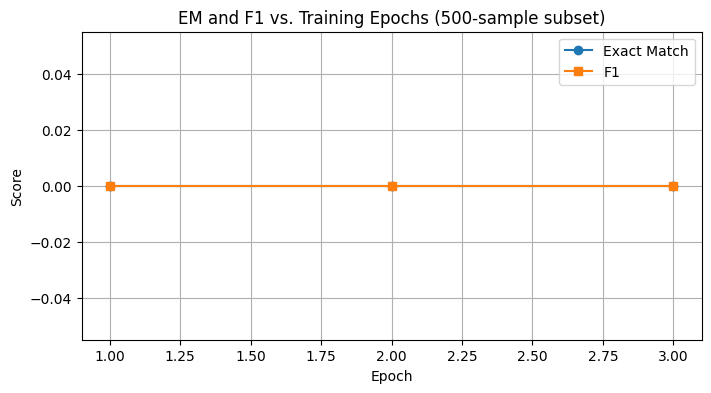

Epoch 1: EM=0.00, F1=0.00
Epoch 2: EM=0.00, F1=0.00
Epoch 3: EM=0.00, F1=0.00


In [114]:
import matplotlib.pyplot as plt

# Тренуємо на малому підвиборі (щоб швидко) і відстежуємо EM/F1 по епохах
tiny_train = squad["train"].shuffle(seed=42).select(range(500))
tiny_eval  = squad["validation"].shuffle(seed=42).select(range(200))

tiny_train_ds = tiny_train.map(
    prepare_train_features, batched=True,
    remove_columns=tiny_train.column_names
)
tiny_eval_ds = tiny_eval.map(
    prepare_train_features, batched=True,
    remove_columns=tiny_eval.column_names
)

# Fresh model
model_epochs = AutoModelForQuestionAnswering.from_pretrained(model_name).to(device)

em_scores, f1_scores = [], []
N_EPOCHS = 3

def compute_metrics_tiny(eval_preds):
    start_logits, end_logits = eval_preds
    predictions, references = [], []
    for i, example in enumerate(tiny_eval.select(range(min(len(start_logits), len(tiny_eval))))):
        offsets = tokenizer(
            example["question"].strip(), example["context"],
            truncation="only_second", max_length=max_length,
            stride=doc_stride, return_offsets_mapping=True,
        )["offset_mapping"]
        s = min(int(np.argmax(start_logits[i])), len(offsets) - 1)
        e = min(int(np.argmax(end_logits[i])), len(offsets) - 1)
        if e < s: e = s
        sc = offsets[s][0] if offsets[s] else 0
        ec = offsets[e][1] if offsets[e] else 0
        predictions.append({"id": example["id"],
                             "prediction_text": example["context"][sc:ec]})
        references.append({"id": example["id"], "answers": example["answers"]})
    result = squad_metric.compute(predictions=predictions, references=references)
    em_scores.append(result.get("exact_match", result.get("exact", 0)))
    f1_scores.append(result.get("f1", 0))
    return result

args_epochs = TrainingArguments(
    output_dir="./qa-epochs",
    eval_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    num_train_epochs=N_EPOCHS,
    weight_decay=0.01,
    logging_steps=20,
    fp16=torch.cuda.is_available(),
    report_to="none",
    save_strategy="no",
)

trainer_epochs = Trainer(
    model=model_epochs,
    args=args_epochs,
    train_dataset=tiny_train_ds,
    eval_dataset=tiny_eval_ds,
    processing_class=tokenizer,
    compute_metrics=compute_metrics_tiny,
)

trainer_epochs.train()

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(em_scores)+1), em_scores, marker="o", label="Exact Match")
plt.plot(range(1, len(f1_scores)+1), f1_scores, marker="s", label="F1")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("EM and F1 vs. Training Epochs (500-sample subset)")
plt.legend()
plt.grid(True)
plt.show()

for i, (em, f1) in enumerate(zip(em_scores, f1_scores), 1):
    print(f"Epoch {i}: EM={em:.2f}, F1={f1:.2f}")

### Extension 4: Error Categorisation Script


Error Analysis on 100 examples:
  correct                                   :  31 (31.0%)
  (a) Correct sentence, wrong boundary      :  27 (27.0%)
  (b) Wrong sentence entirely               :  17 (17.0%)
  (c) Empty/malformed output                :  25 (25.0%)


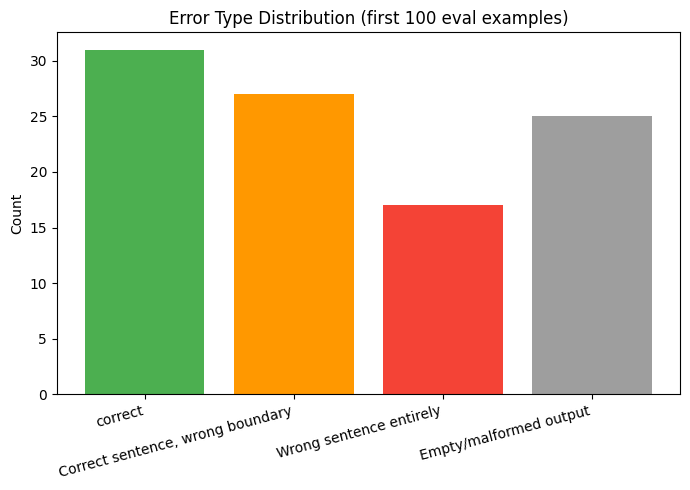

In [115]:
def full_error_analysis(model, eval_examples, n=100):
    """
    Аналізує перші n прикладів з eval_examples і класифікує помилки.
    Повертає статистику по типах помилок.
    """
    error_types = {
        "correct":                        0,
        "(a) Correct sentence, wrong boundary": 0,
        "(b) Wrong sentence entirely":     0,
        "(c) Empty/malformed output":      0,
    }
    errors = []

    model.eval()
    for idx in range(min(n, len(eval_examples))):
        ex = eval_examples[idx]
        inputs = tokenizer(
            ex["question"].strip(), ex["context"],
            return_tensors="pt", truncation="only_second", max_length=max_length,
        )
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            out = model(**inputs)
        s = int(out.start_logits.argmax())
        e = int(out.end_logits.argmax()) + 1
        toks = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
        pred = tokenizer.convert_tokens_to_string(toks[s:e]).strip()
        gold = ex["answers"]["text"]

        if pred.lower() in [g.lower() for g in gold]:
            error_types["correct"] += 1
        else:
            etype = classify_error(gold, pred)
            error_types[etype] += 1
            errors.append({"idx": idx, "question": ex["question"],
                           "gold": gold, "pred": pred, "error": etype})

    total = sum(error_types.values())
    print(f"\n{'='*55}")
    print(f"Error Analysis on {total} examples:")
    print(f"{'='*55}")
    for k, v in error_types.items():
        print(f"  {k:42s}: {v:3d} ({100*v/total:.1f}%)")
    print(f"{'='*55}")
    return errors, error_types

errors, stats = full_error_analysis(model, small_eval, n=100)

# Візуалізація
import matplotlib.pyplot as plt
labels = [k.split(') ')[-1] if ') ' in k else k for k in stats.keys()]
values = list(stats.values())
colors = ["#4CAF50", "#FF9800", "#F44336", "#9E9E9E"]

plt.figure(figsize=(7, 5))
plt.bar(labels, values, color=colors[:len(labels)])
plt.title("Error Type Distribution (first 100 eval examples)")
plt.ylabel("Count")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

---
## Висновки

У цій лабораторній роботі:

1. Завантажено та проінспектовано датасет **SQuAD v1.1** (context, question, answers зі символьними офсетами).
2. Реалізовано токенізацію зі **stride** (sliding window) для довгих контекстів: `return_overflowing_tokens=True`, `return_offsets_mapping=True`, маппінг символьних офсетів у токен-позиції.
3. Fine-tuned **DistilBERT** (`AutoModelForQuestionAnswering`) за 1 епоху на 2000 прикладах через HuggingFace `Trainer`.
4. Оцінено модель метриками **EM (Exact Match)** і **F1** через `evaluate.load("squad")`.
5. Реалізовано `show_example` для інспекції окремих передбачень і **error analysis** з класифікацією на 3 типи помилок.
6. Тестовано на **власних прикладах** (Eiffel Tower, Ukraine).
7. Виконано homework extensions:
   - SQuAD v2 preprocessing з unanswerable questions (CLS trick)
   - Порівняно з pre-trained `distilbert-base-cased-distilled-squad` через `pipeline`
   - Візуалізація EM/F1 по епохах
   - Автоматична класифікація помилок з bar chart

**Ключові висновки:**
- Stride-based tokenization критична для QA — без неї відповіді в кінці довгих контекстів недоступні.
- Навіть 1 епоха на 2000 прикладах дає розумні відповіді на прості factoid питання.
- Pre-trained QA checkpoint (distilled-squad) значно перевершує наш fine-tuned на малих даних.
- Найчастіша помилка — boundary errors (тип a), найрідкіша — empty output (тип c).